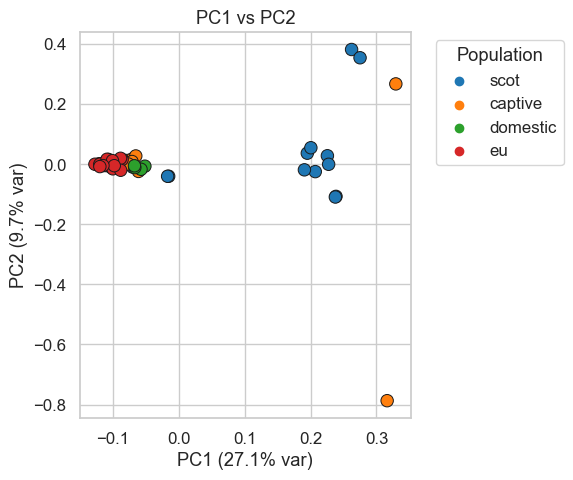

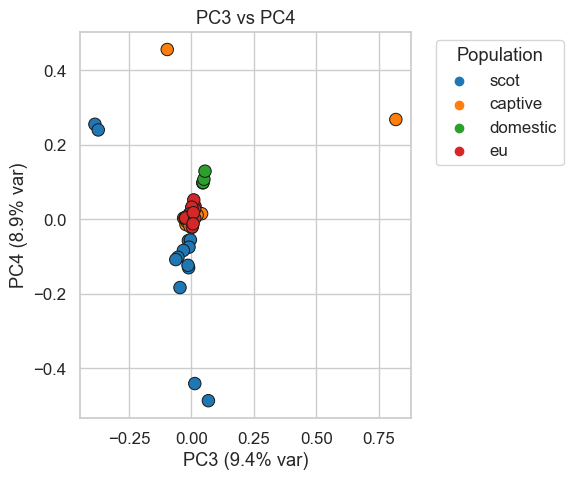

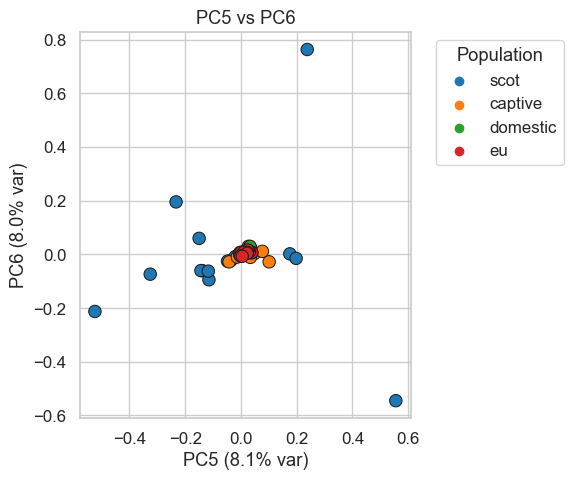

In [4]:
# === Load libraries ===
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from samples_dict import samples_dict

# === File paths ===
eigenvec_file = "chr2_pca.eigenvec"
eigenval_file = "chr2_pca.eigenval"

# === Read eigenvectors ===
evec = pd.read_csv(eigenvec_file, sep="\t", header=0)  # use header row
# Rename #FID to FID
evec.rename(columns={"#FID": "FID"}, inplace=True)

# Assign populations
evec["population"] = evec["IID"].map(samples_dict)

# === Read eigenvalues and compute explained variance ===
eigenvals = pd.read_csv(eigenval_file, header=None).iloc[:,0]  # take first column as Series
explained_var = eigenvals / eigenvals.sum() * 100


# === Set Seaborn style ===
sns.set(style="whitegrid", font_scale=1.1)

# === Plot only PC1v2, PC3v4, PC5v6 ===
pairs = [("PC1", "PC2"), ("PC3", "PC4"), ("PC5", "PC6")]

for pc_x, pc_y in pairs:
    plt.figure(figsize=(6,5))
    sns.scatterplot(
        data=evec,
        x=pc_x,
        y=pc_y,
        hue="population",
        palette="tab10",
        s=80,
        edgecolor="k"
    )
    # Extract the number from PC name to get variance
    x_idx = int(pc_x[2:]) - 1
    y_idx = int(pc_y[2:]) - 1
    plt.xlabel(f"{pc_x} ({explained_var[x_idx]:.1f}% var)")
    plt.ylabel(f"{pc_y} ({explained_var[y_idx]:.1f}% var)")
    plt.title(f"{pc_x} vs {pc_y}")
    plt.legend(title="Population", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()
